# **Task B**

- Name : Vaishnavi Agarwal
- Roll No.: 230150028

# Importing Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
from IPython.display import display, Image

# **(a) Data Preparation**

In [13]:
svg_path = "iitg_logo.svg"

def sample_path(path, pts_per_seg=300):
    xs = []
    ys = []
    for seg in path:
        ts = np.linspace(0, 1, pts_per_seg, endpoint=False)
        pts = np.array([seg.point(t) for t in ts])
        xs.extend(pts.real.tolist())
        ys.extend((-pts.imag).tolist())  # flip Y for plotting
    # close contour
    if len(xs) > 0:
        xs.append(xs[0])
        ys.append(ys[0])
    return np.array(xs), np.array(ys)

paths, attributes = spt.svg2paths(svg_path)
contours = []
for path in paths:
    x, y = sample_path(path, pts_per_seg=300)
    if len(x) > 5 and (np.ptp(x) > 1e-9 or np.ptp(y) > 1e-9):
        contours.append((x, y))

print(f"Found {len(contours)} non-trivial contour(s)")

Found 8 non-trivial contour(s)


In [14]:
def resample_uniform(x, y, N=4096):
    dx = np.diff(x)
    dy = np.diff(y)
    seglen = np.sqrt(dx*dx + dy*dy)
    cumlen = np.concatenate(([0.0], np.cumsum(seglen)))
    total = cumlen[-1]
    if total == 0:
        return x, y
    us = np.linspace(0, total, N, endpoint=False)
    x_u = np.interp(us, cumlen, x)
    y_u = np.interp(us, cumlen, y)
    return x_u, y_u

N_resample = 4096
z_contours = []
for x, y in contours:
    xu, yu = resample_uniform(x, y, N=N_resample)
    z_contours.append(xu + 1j*yu)


In [15]:
coeffs_list = []
for z in z_contours:
    N = len(z)
    C = np.fft.fftshift(np.fft.fft(z)) / N
    coeffs_list.append(C)

Found 8 non-trivial contour(s)
Saving GIF (this may take a moment)...
Saved files:
 - GIF: fourier_reconstruction.gif


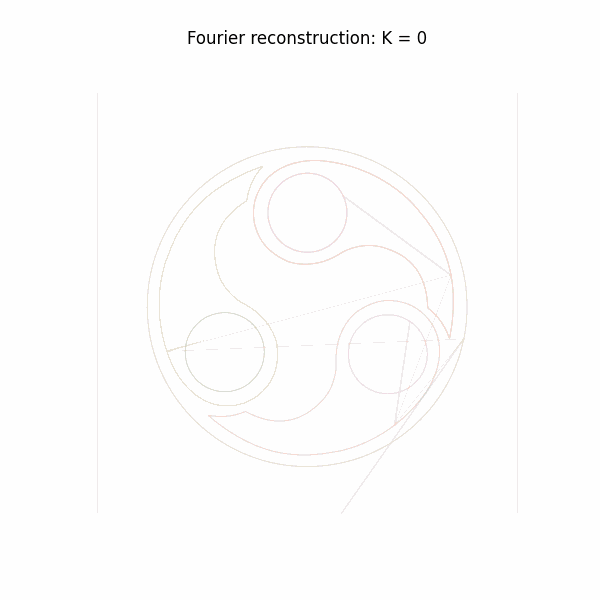

In [ ]:






# -------------------------
# 2) Resample uniformly by arc-length
# -------------------------

# -------------------------
# 3) Fourier coefficients (FFT)
# -------------------------


# -------------------------
# 4) Reconstruction helper
# -------------------------
def reconstruct_from_coeffs(C, K):
    N = len(C)
    ks = np.arange(-N//2, N//2)
    Ck = np.zeros_like(C)
    sel = np.abs(ks) <= K
    Ck[sel] = C[sel]
    z_hat = np.fft.ifft(np.fft.ifftshift(Ck) * N)
    return z_hat

# -------------------------
# 5) Create animation frames (progressively increase K)
# -------------------------
K_max = 150  # choose based on speed & quality; reduce if slow
K_values = list(range(0, K_max+1, 5))
frames = []
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)
ax.set_axis_off()
ax.set_aspect('equal')

# plotting limits
all_x = np.hstack([z.real for z in z_contours])
all_y = np.hstack([z.imag for z in z_contours])
pad = 0.05 * max(np.ptp(all_x), np.ptp(all_y))
xlim = (all_x.min()-pad, all_x.max()+pad)
ylim = (all_y.min()-pad, all_y.max()+pad)

orig_plots = [(z.real, z.imag) for z in z_contours]

for K in K_values:
    ax.clear()
    ax.set_axis_off()
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    # faint original overlay
    for xr, yr in orig_plots:
        ax.plot(xr, yr, alpha=0.12, linewidth=1)
    # reconstructed contours
    for C in coeffs_list:
        zhat = reconstruct_from_coeffs(C, K)
        ax.plot(zhat.real, zhat.imag, linewidth=1.6)
    ax.set_title(f"Fourier reconstruction: K = {K}", pad=20)
    fig.canvas.draw()
    img = np.frombuffer(fig.canvas.buffer_rgba(), dtype='uint8')
    img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))

    frames.append(img.copy())

plt.close(fig)

# -------------------------
# 6) Save GIF 
# -------------------------
gif_path = "fourier_reconstruction.gif"

print("Saving GIF (this may take a moment)...")
imageio.mimsave(gif_path, frames, fps=2)

print("Saved files:")
print(" - GIF:", gif_path)

display(Image(filename=gif_path))


# **Trade-off between number of Fourier terms and reconstruction quality:**
More Fourier terms (higher K) allow the series to approximate higher-frequency components of the shape (sharper corners, finer curvature), so reconstruction quality increases with K. However, increasing K increases computation cost and may produce high-frequency ringing (Gibbs) around discontinuities.

# **Why Fourier series can capture highly irregular shapes:**
Any sufficiently well-behaved periodic (or periodicized) function can be represented as a sum of sinusoids. Parametric contours (x(t), y(t)) sampled uniformly in t are periodic signals. The Fourier basis spans oscillations at all frequencies, so combining those gives you arbitrary shapes The higher the frequency content, the more irregularity can be represented.

# **Real-world applications:**

*Shape compression:* store contours compactly by keeping only the largest Fourier coefficients (used in vector compression and signature descriptors).

*Handwriting / signature analysis:* represent handwriting strokes by Fourier descriptors for recognition/authentication.

*Path planning:* approximating obstacle contours smoothly for collision checking and trajectory planning.

*Motion/shape interpolation:* animate shapes by interpolating coefficients.

*Medical imaging:* boundary shape analysis for cells/organs.